In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

In [21]:
hours = np.arange(1, 11)  # Study hours as feature
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100]) # Continuous target

df = pd.DataFrame({
    'StudyHours': hours,
    'Marks': marks,
})

print(df)

lin_reg = LinearRegression()
df_studyhours = df[['StudyHours']]
df_marks = df[['Marks']]

lin_reg.fit(df_studyhours, df_marks)

   StudyHours  Marks
0           1     10
1           2     20
2           3     35
3           4     50
4           5     65
5           6     70
6           7     85
7           8     90
8           9     95
9          10    100


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
print(lin_reg.predict([[4.5]]))

[[51.57575758]]


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
hours = np.arange(1, 11)  # Study hours as feature
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100]) # Continuous target
pass_fail = np.where(marks >= 50, 1, 0)  # Binary target: 1=Pass, 0=Fail

df = pd.DataFrame({
    'StudyHours': hours,
    'PassFail': pass_fail
})
print(df)

df_studyhours = df[['StudyHours']]
df_passfail = df[['PassFail']]
log_reg = LogisticRegression()
log_reg.fit(df_studyhours, df_passfail)

   StudyHours  PassFail
0           1         0
1           2         0
2           3         0
3           4         1
4           5         1
5           6         1
6           7         1
7           8         1
8           9         1
9          10         1


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
print(log_reg.predict([[4.5],[1],[2],[10]]))

[1 0 0 1]


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [25]:
pred_failpass = log_reg.predict_proba([[2]]) # Study hours for predict
print(pred_failpass)

[[0.84707214 0.15292786]]


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


   StudyHours  Marks  PassFail
0           1     10         0
1           2     20         0
2           3     35         0
3           4     50         1
4           5     65         1
5           6     70         1
6           7     85         0
7           8     90         0
8           9     95         1
9          10    100         1


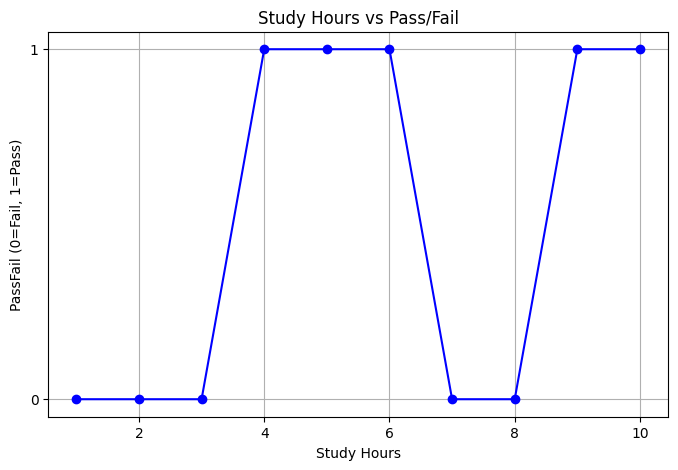

In [26]:
hours = np.arange(1, 11)  # Study hours as feature
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100]) # Continuous target
pass_fail = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1])  # Binary target: 1=Pass, 0=Fail

df = pd.DataFrame({
    'StudyHours': hours,
    'Marks': marks,
    'PassFail': pass_fail
})

print(df)

plt.figure(figsize=(8,5))
plt.plot(df['StudyHours'], df['PassFail'], marker='o', color='blue')
plt.title("Study Hours vs Pass/Fail")
plt.xlabel("Study Hours")
plt.ylabel("PassFail (0=Fail, 1=Pass)")
plt.yticks([0,1])
plt.grid(True)
plt.show()

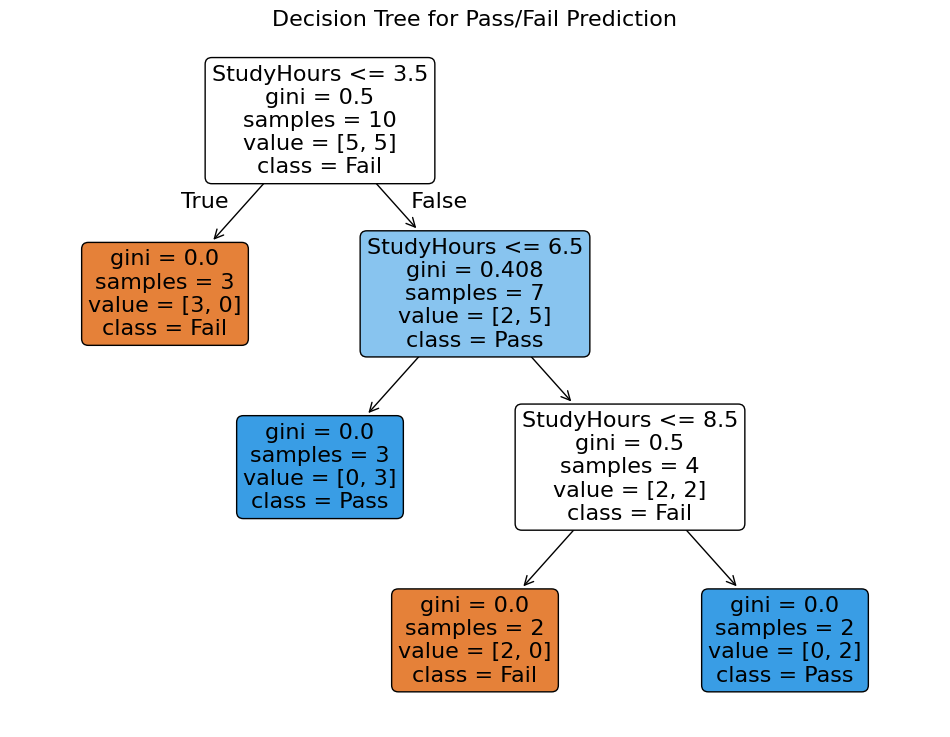

[0]


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

hours = np.arange(1, 11)  # Study hours as feature
marks = np.array([10, 20, 35, 50, 65, 70, 85, 90, 95, 100]) # Continuous target
pass_fail = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1])  # Binary target: 1=Pass, 0=Fail

df = pd.DataFrame({
    'StudyHours': hours,
    'Marks': marks,
    'PassFail': pass_fail
})

X=df[['StudyHours']]
y = df[['PassFail']]

dtc= DecisionTreeClassifier()
dtc.fit(X,y)

plt.figure(figsize=(12,9))  # Larger figure
plot_tree(
    dtc,
    feature_names=['StudyHours'],
    class_names=['Fail','Pass'],
    filled=True,
    rounded=True,
    fontsize=16  # Bigger font
)
plt.title("Decision Tree for Pass/Fail Prediction", fontsize=16)
plt.show()

print(dtc.predict([[7.5]]))